## Creating a Logistic Regression Model

### Discovery

You have been tasked with trying to determine if there is a linear relationship between the patients cholesterol levels and other characteristics. You will use a linear regression model to establish if any relationship exists and if so, how cholesterol levels are impacted by other chemicals, substances and health measures. 

First we will import the required modules. They are:
- pandas
- seaborn
- statsmodels.api
- sklearn.model_selection - train_test_split
- sklearn.metrics - confusion_matrix
- matplotlib.pyplot

In [1]:
# Import required modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

--- 
### Data preparation
Import the diabetes dataset and restrict to the required columns.

In [2]:
# Import the first dataset and set the date as the index
diabetes_df = pd.read_csv("diabetes.csv")
diabetes_df

,Age,Gender,BMI,SBP,DBP,FPG,Chol,Tri,HDL,LDL,ALT,BUN,CCR,FFPG,smoking,drinking,family_histroy,Diabetes
0,26,1,20.1,119,81,5.80,4.36,0.86,0.90,2.43,12.0,5.40,63.8,5.40,3.000000,3.000000,0,0
1,40,1,17.7,97,54,4.60,3.70,1.02,1.50,2.04,9.2,3.70,70.3,4.10,1.000000,1.000000,0,0
2,40,2,19.7,85,53,5.30,5.87,1.29,1.75,3.37,10.1,4.10,61.1,4.85,3.000000,3.000000,0,0
3,43,1,23.1,111,71,4.50,4.05,0.74,1.27,2.60,36.5,4.38,73.4,5.30,2.000000,3.000000,0,0
4,36,1,26.5,130,82,5.54,6.69,3.49,0.91,3.64,69.3,3.86,67.5,5.53,3.000000,3.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4298,54,1,23.4,126,75,6.82,5.00,1.50,1.24,2.98,8.0,3.50,77.0,6.70,1.000000,3.000000,0,1
4299,50,2,22.3,115,84,5.32,4.37,2.09,1.37,2.29,21.2,4.40,47.3,6.55,4.860753,4.860753,0,1
4300,67,1,24.6,138,81,4.85,3.89,1.38,1.14,2.17,18.1,4.73,70.6,6.80,3.000000,3.000000,0,1
4301,60,2,29.0,101,60,6.70,5.91,1.29,1.73,2.85,18.9,7.33,50.2,7.00,3.000000,3.000000,0,1


Strip out some of the values from the dataset, I want to include the following columns:
- Age
- BMI
- Chol
- HDL
- LDL
- SBP

In [3]:
# Set the dataframe to only include required columns
diabetes_df = diabetes_df [["Age","BMI","Chol","HDL","LDL","SBP"]]
diabetes_df

,Age,BMI,Chol,HDL,LDL,SBP
0,26,20.1,4.36,0.90,2.43,119
1,40,17.7,3.70,1.50,2.04,97
2,40,19.7,5.87,1.75,3.37,85
3,43,23.1,4.05,1.27,2.60,111
4,36,26.5,6.69,0.91,3.64,130
...,...,...,...,...,...,...
4298,54,23.4,5.00,1.24,2.98,126
4299,50,22.3,4.37,1.37,2.29,115
4300,67,24.6,3.89,1.14,2.17,138
4301,60,29.0,5.91,1.73,2.85,101


In [4]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4303 entries, 0 to 4302
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     4303 non-null   int64  
 1   BMI     4303 non-null   float64
 2   Chol    4303 non-null   float64
 3   HDL     4303 non-null   float64
 4   LDL     4303 non-null   float64
 5   SBP     4303 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 201.8 KB


--- 
### Model planning
You will now need to understand which variables can help you determine whether we will hit the predetermined threshold or not. To begin with, we need to understand our data a little more. Lets get the mean and median oil price.  

In [5]:
#Get the mean and median prices from the dataset and print them in a single line of code. 
mean_price = diabetes_df["Chol"].mean()
med_price = diabetes_df["Chol"].median()
print(f"The mean price is {mean_price} and the median price is {med_price}.")

The mean price is 4.86075308900767 and the median price is 4.79.


Next we want to create a histogram to understand the distribution of price, to understand what high prices might look like. Once we have this, we can create a binary field in our dataset, showing us whether we have hit the threshold or not. 

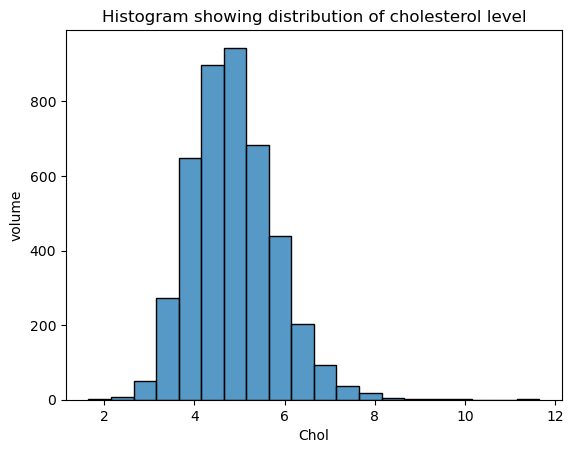

In [6]:
# Create a historgram to determine a suitable threshold. 
hist = sns.histplot(x = "Chol",
             data = diabetes_df,
             bins = 20)
hist.set_ylabel("volume")
hist.set_title("Histogram showing distribution of cholesterol level")
plt.show()

In [7]:
# Create a new binary column in the dataframe which will be True/False based on the threshold
diabetes_df["high_chol"] = diabetes_df["Chol"] >= 6
diabetes_df

C:\Users\CharlesArthur\AppData\Local\Temp\ipykernel_26156\1684679734.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diabetes_df["high_chol"] = diabetes_df["Chol"] >= 6


,Age,BMI,Chol,HDL,LDL,SBP,high_chol
0,26,20.1,4.36,0.90,2.43,119,False
1,40,17.7,3.70,1.50,2.04,97,False
2,40,19.7,5.87,1.75,3.37,85,False
3,43,23.1,4.05,1.27,2.60,111,False
4,36,26.5,6.69,0.91,3.64,130,True
...,...,...,...,...,...,...,...
4298,54,23.4,5.00,1.24,2.98,126,False
4299,50,22.3,4.37,1.37,2.29,115,False
4300,67,24.6,3.89,1.14,2.17,138,False
4301,60,29.0,5.91,1.73,2.85,101,False


Now we can determine which variables will help us to determine if we will hit this threshold or not. We will first create a table, aggregating our dataset by our binary column. I'll use this to calculate the mean of each binary outcome. 

In [8]:
# Create aggregate table on the true/false column. Find the mean value. Variables should have distinct differences in the mean.
diabetes_df.groupby("high_chol").mean()

,Age,BMI,Chol,HDL,LDL,SBP
high_chol,,,,,,
False,47.312222,24.007778,4.644010,1.640312,2.843039,122.576289
True,54.211618,25.044647,6.578963,1.876465,4.032001,128.317427


Next create a box plot with an independent vairable and your target variable (your true/false column).

Text(0.5, 1.0, 'Boxplot to show close distrubtion between False and True groups')

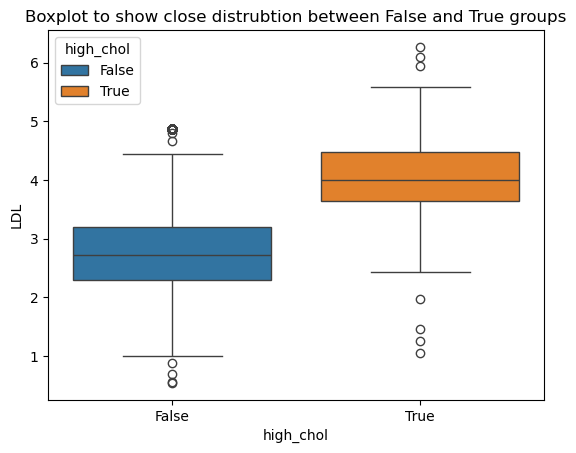

In [27]:
# Create a box plot to show the differences in distribution between your true and false groups
box = sns.boxplot(x = "high_chol",
                  y = "LDL",
                  data = diabetes_df,
                  hue = "high_chol")

# Set title
box.set_title("Boxplot to show close distrubtion between False and True groups")

Finally, a correlation matrix will help us to see if there is a strong relationship between our dependent and independent variable. 

<Axes: >

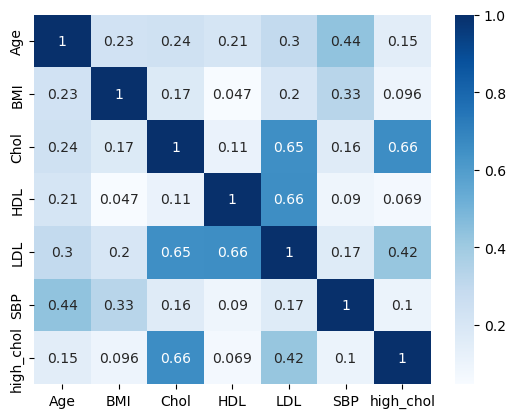

In [28]:
# Create a correlation matrix to demonstrate relationships between our variables
join_corr = diabetes_df.corr()
sns.heatmap(join_corr, annot=True, cmap="Blues")

---
### Building the model
Split the data into training and test datasets - include the random_state argument:<br>
random_state = 25

In [11]:
# Split the data into train and test samples
train, test = train_test_split(diabetes_df,random_state=25)

Set both the independent variable and dependent variable - remember to check they are set correctly. Don't forget to add a constant to your independent variables. 

In [12]:
# Set the dependent variable and validate
dep = train["high_chol"]
dep.head()

1865    False
2781    False
4238    False
1392    False
1532    False
Name: high_chol, dtype: bool

In [13]:
# Set the independent variable and validate
ind = train[["LDL"]]
ind.head()

,LDL
1865,1.90
2781,2.10
4238,2.70
1392,2.63
1532,1.60


In [14]:
# Remember to add the constant 
ind = sm.add_constant(ind)
ind.head()

,const,LDL
1865,1.0,1.90
2781,1.0,2.10
4238,1.0,2.70
1392,1.0,2.63
1532,1.0,1.60


Now generate the logistic regression model along with a summary output. 

In [15]:
# Fit the model and produce the summary
model = sm.Logit(dep,ind).fit()
model.summary()

# Model 1 with age and SBP  - PRS 0.2374
# Model 2 without - PRS 0.2344

Optimization terminated successfully.
         Current function value: 0.273136
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              high_chol   No. Observations:                 3227
Model:                          Logit   Df Residuals:                     3225
Method:                           MLE   Df Model:                            1
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.2344
Time:                        10:25:26   Log-Likelihood:                -881.41
converged:                       True   LL-Null:                       -1151.3
Covariance Type:            nonrobust   LLR p-value:                2.070e-119
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.8377      0.261    -26.214      0.000      -7.349      -6.326
LDL            1.4072      0.067     20.998      0.000       1.276       1.539
==============================================================================
"""

--- 
### Communicating the results. 
You will now analyse the model and communicate the results. What do the following outputs tell you about the model

- Pseudo R-Squared:
- P-Value:
- Coefficient:

In [16]:
# Use the model to predict which dates we are likely to hit high oil prices. Check the output.
predictions = model.predict(ind) >= 0.5
#pred_num = model.predict(ind)
predictions.head()
#pred_num.head()

1865    False
2781    False
4238    False
1392    False
1532    False
dtype: bool

Once we have our preductions - we can use these to create a confusion matrix, which will help us to assess the model quality. 

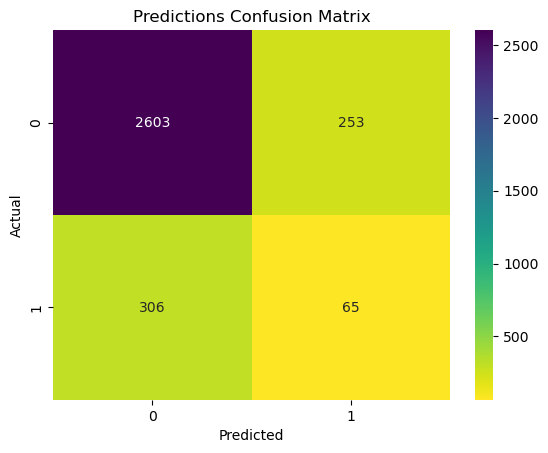

In [17]:
# Generate a confusion matrix to test the model
conf_mat = confusion_matrix(dep, predictions)

# (Optional) Generate the confusion matrix as a heatmap
confusion_mat_heatmap = sns.heatmap(conf_mat, annot = True, cmap = 'viridis_r', fmt='g')

# (Optional) set x and y labels, and create a title
confusion_mat_heatmap.set_xlabel('Predicted')
confusion_mat_heatmap.set_ylabel('Actual')
confusion_mat_heatmap.set_title("Predictions Confusion Matrix")
plt.show()

The model was correct in 2775 cases; 

The model was incorrect in 452 cases. 

Total = 3227 cases

That's a great overall success rate! 
2775/3227 * 100 = 85% accuracy

**Basic Terminology**

**True Positives (TP)** is 65: The model correctly predicted a large purchase. (Bottom right)

**True Negatives (TN)** is 2603: The model correctly predicted that it wont be a large purchase. (Top left)

**False Positives (FP)** is 253: The model incorrectly predicted a large purchase. (Top right)

**False Negatives (FN)** is 306: The model incorrectly predicted it wont be a large purchase. (Bottom left)

In [18]:
# Check incorrectly predicted rows
output = model.predict(ind) >= 0.5
train["predicted"] = output
train = train[["LDL","high_chol","predicted"]]
inc_diff = train[train["high_chol"] != train["predicted"]]
inc_diff.head()
inc_diff["LDL"].median()

4.53

In [19]:
# Test the model 
dep_test = test["high_chol"]
ind_test = test[["LDL"]]
ind_test = sm.add_constant(ind_test)

# Produce the output and save to a dataframe column - then validate
output = model.predict(ind_test) >= 0.5
num_ouput = model.predict(ind_test)
test["predicted"] = output
test["numeric_predicted"] = num_ouput

# (Optional) Create a dataframe where only incorrect predictions are displayed
test = test[["LDL","high_chol","predicted","numeric_predicted"]]
inc_diff = test[test["high_chol"] != test["predicted"]]
inc_diff

,LDL,high_chol,predicted,numeric_predicted
1096,4.760000,True,False,0.465250
2859,4.110000,True,False,0.258470
4229,4.860753,False,True,0.500639
1297,3.790000,True,False,0.181792
597,3.950000,True,False,0.217704
...,...,...,...,...
3068,4.860753,False,True,0.500639
3863,4.860753,False,True,0.500639
3110,4.860753,False,True,0.500639
1292,4.360000,True,False,0.331341


In [20]:
print(diabetes_df.loc[597])

Age            33
BMI          24.7
Chol         6.43
HDL          1.21
LDL          3.95
SBP           126
high_chol    True
Name: 597, dtype: object


<Axes: xlabel='LDL', ylabel='numeric_predicted'>

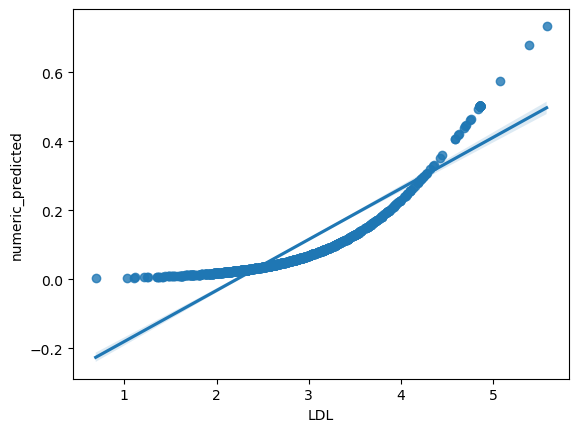

In [21]:
sns.regplot(x = "LDL",
            y = "numeric_predicted",
            data = test)

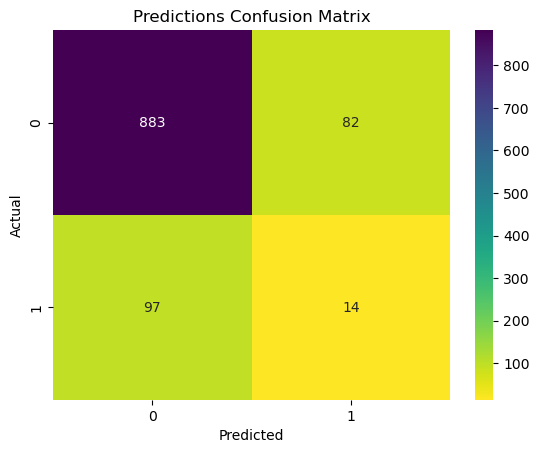

In [22]:
# (Optional) Create a confusion matrix to display test results

tconf_mat = confusion_matrix(dep_test,output)
tconf_mat

# (Optional) Replicate the results as a heatmap as before:
tconfusion_mat_heatmap = sns.heatmap(tconf_mat, annot = True, cmap = 'viridis_r', fmt='g')

# (Optional) set x and y labels, and create a title
tconfusion_mat_heatmap.set_xlabel('Predicted')
tconfusion_mat_heatmap.set_ylabel('Actual')
tconfusion_mat_heatmap.set_title("Predictions Confusion Matrix")
plt.show()

---
### Stretch task
Create a new dataframe with some example data, and generate some predictions using your model.

--- 

In [23]:
# Create a new dataframe

In [24]:
# Generate predictions

In [25]:
# Generate results in the dataframe, based on new dataset

--- 
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production level servers, produce technical documentation and build this into your BAU process. This being a fictional company, the ever grateful management have granted you paid leave for all your hard work and have volunteered to take on this burden themselves. Congratulations and well done!